In [1]:
# !pip install 'zarr<3'
# !pip install timm


In [2]:
# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"✅ Working directory: {os.getcwd()}")

✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest


In [3]:
# Cell 3: Import and create dataloaders
from dataset import Config, create_dataloaders

# Just use the correct relative path from your working directory
config = Config("configs/training/config_fold32.yaml")  # Note: "configs" not "config"
config.print_config()

train_loader, val_loader, test_loader = create_dataloaders(config)
print("\n✅ Ready to use!")

✅ CRC Dataset Package v1.0.0 loaded
CRC DATASET CONFIGURATION
Config File: configs/training/config_fold32.yaml
Zarr Base: /rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/ORION-CRC/zarr_data
Cache: Disabled
Strategy: memory

📊 Data Splits:
  Train: 54 samples
  Val: 17 samples
  Test: 15 samples

🔄 DataLoader:
  Batch Size: 4
  Num Workers: 16
  Pin Memory: True

🎨 Augmentation:
  Training: True
  Probability: 1.0

🎯 HV Maps:
  Generate: True
  Method: pannuke
  HE Nuclei: True
  HE Cells: True
  MIF Nuclei: True
  MIF Cells: True

🔍 Filtering:
  Min Instances: 0
  Filter Empty: True

CREATING DATALOADERS
Strategy: memory
Use Cache: False
Batch Size: 4
Num Workers: 16
Train split: 35 CRC + 7 Xenium + 1 TissueNet + 1 PanNuke + 1 Lizard + 1 MoNuSeg + 1 MoNuSAC + 1 TNBC + 1 NuInsSeg + 1 CryoNuSeg + 1 BC + 1 CoNSeP + 1 Kumar + 1 CPM17
Val   split: 3 CRC + 2 Xenium + 1 TissueNet + 1 PanNuke + 1 Lizard + 1 MoNuSeg + 1 MoNuSAC + 1 TNBC + 1 NuInsSeg + 1 CryoNuSeg + 1 BC + 1 CoNSeP + 1 

/home/yshokrollahi/.local/lib/python3.11/site-packages/plink/gui.py:33: UserWarning: Plink failed to import tkinter, GUI will not be available
  warnings.warn('Plink failed to import tkinter, GUI will not be available')


  ✅ lizard_train (lizard): 865 patches
  ✅ monuseg monuseg_train: 136 patches loaded
  ✅ tnbc tnbc_train: 33 patches loaded
  ✅ nuinsseg_train (nuinsseg): 465 patches
  ✅ cryonuseg_train (cryonuseg): 20 patches
  ✅ bc_train (bc): 347 patches
  ✅ consep_train (consep): 100 patches
  ✅ monusac monusac_train: 596 patches loaded
  ✅ kumar_train (kumar): 144 patches
  ✅ cpm17_train (cpm17): 52 patches
  ✅ breast (xenium): 145 patches
  ✅ cervical (xenium): 54 patches
  ✅ lung (xenium): 66 patches
  ✅ lymph_node (xenium): 53 patches
  ✅ ovarian (xenium): 94 patches
  ✅ skin (xenium): 205 patches
  ✅ pancreasV1 (xenium): 78 patches
  ✅ CRC01 (crc): 36 patches
  ✅ CRC02 (crc): 75 patches
  ✅ CRC04 (crc): 118 patches
  ✅ CRC05 (crc): 696 patches
  ✅ CRC06 (crc): 147 patches
  ✅ CRC07 (crc): 130 patches
  ✅ CRC08 (crc): 115 patches
  ✅ CRC10 (crc): 27 patches
  ✅ CRC12 (crc): 69 patches
  ✅ CRC13 (crc): 38 patches
  ✅ CRC14 (crc): 18 patches
  ✅ CRC15 (crc): 18 patches
  ✅ CRC16 (crc): 142 patch

## Flex model

In [6]:
import torch
from vitaminp import VitaminPFlex
from vitaminp.inference import ChannelConfig, WSIPredictor
# Setup model
device = 'cuda'
model = VitaminPFlex(model_size='large').to(device)
model.load_state_dict(torch.load("checkpoints/vitamin_p_flex_large_fold32_hv4_mag_lr1e4_best.pth", map_location=device))
model.eval()

✓ VitaminPFlex PRO initialized with large backbone
  + ASPP Bridge Active (Context Enhancement)
  + CoordConv Heads Active (Spatial Awareness)


VitaminPFlex(
  (backbone): DINOv2Backbone(
    (dinov2): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): M

## Single slide

In [8]:
from vitaminp.inference import WSIPredictor
from vitaminp.inference.channel_config import ChannelConfig

# 1. Setup Model (Standard)
# model = ... (load your model as usual)

# 2. Initialize Predictor
predictor = WSIPredictor(
    model=model,
    device='cuda',
    patch_size=512,
    overlap=64,
    target_mpp=0.2125,
    magnification=40,
    batch_size=128,
    tissue_dilation = 1,

)

# 3. RUN INFERENCE (The Magic Step)
# By passing BOTH branches, the predictor automatically switches to 
# the new "Joint Inference" mode where Nuclei constrain the Cells.
results = predictor.predict(
    wsi_path='test_images/CRC18-he_chunk_0.png',
    output_dir='results_joint_constrained/',
    
    # [!] THIS TRIGGERS THE NEW LOGIC
    branches=['he_nuclei','he_cell'], 
    
    # Standard settings
    filter_tissue=True,
    tissue_threshold=0.10,
    clean_overlaps=True,
    save_geojson=True,
    save_parquet=False,       # Saves fast-loading parquet files
    simplify_epsilon=None,    # Smoother contours
    coord_precision=None,        # Smaller file size
    min_area_um=10.0,
)


2026-02-13 20:52:34 - WSIPredictor - INFO - WSIPredictor initialized:
2026-02-13 20:52:34 - WSIPredictor - INFO -   Device: cuda
2026-02-13 20:52:34 - WSIPredictor - INFO -   Model type: VitaminPFlex (single-modality)
2026-02-13 20:52:34 - WSIPredictor - INFO -   Batch Size: 128
2026-02-13 20:52:34 - WSIPredictor - INFO - 🔍 Resolution: MPP=0.2125, scale=1.00x, Batch Size=128
2026-02-13 20:52:34 - WSIPredictor - INFO - 🧠 Running Batch Inference...


   Virtual upscaled size: 512x512 (from 512x512)
   Scanning 1x1 tile grid...
   Tissue dilation: 1 → 1 tiles (+0 boundary tiles)


Processing: 100%|██████████| 1/1 [00:00<00:00,  1.15it/s]
2026-02-13 20:52:35 - WSIPredictor - INFO -    ✓ Extracted 200 instances (before cleaning)
2026-02-13 20:52:35 - WSIPredictor - INFO - 🧹 Cleaning overlapping instances at tile boundaries...
2026-02-13 20:52:35 - WSIPredictor - INFO -    🔍 Starting with 200 instances
2026-02-13 20:52:35 - WSIPredictor - INFO -    📍 Phase 1: Hard Drop (directional boundary cleaning)
2026-02-13 20:52:35 - WSIPredictor - INFO -    ✓ Hard Drop removed 0, survivors: 200
2026-02-13 20:52:35 - WSIPredictor - INFO -    🔄 Phase 2: Iterative overlap removal
2026-02-13 20:52:35 - WSIPredictor - INFO -       Iteration 1: 0 overlaps, kept 200/200
2026-02-13 20:52:35 - WSIPredictor - INFO -       ✓ Converged!
2026-02-13 20:52:35 - WSIPredictor - INFO -    ✅ Final count: 200 instances
2026-02-13 20:52:35 - WSIPredictor - INFO -    ✓ Removed 0, remaining: 200
2026-02-13 20:52:35 - WSIPredictor - INFO - ✅ he_nuclei: 200 detections
2026-02-13 20:52:35 - WSIPredict


🦎 Finding Lizard samples...
Found 88 Lizard samples so far, stopping search...
✅ Found 88 Lizard samples total

🎲 Selected Random Lizard Sample Index: 1080
🖼️ Processing Sample: lizard_test (Source: lizard)

📊 METRIC VERIFICATION

🔍 --- H&E NUCLEI METRIC EXPLANATION ---
  Ground Truth: 150 | Predicted: 65
  TP: 28 | FP: 37 | FN: 122
  SQ: 0.7060 | DQ: 0.2605 | PQ: 0.1839

❌ --- H&E CELLS INVALID ---
   Reason: GT is empty, but model predicted 84 instances (Pure False Positives).

⚠️ --- MIF NUCLEI SKIPPED ---
   Reason: Both Ground Truth and Prediction are empty (Missing Modality).

⚠️ --- MIF CELLS SKIPPED ---
   Reason: Both Ground Truth and Prediction are empty (Missing Modality).

ℹ️ Note: MIF image has 2 channels. Collapsing to mean intensity for display.


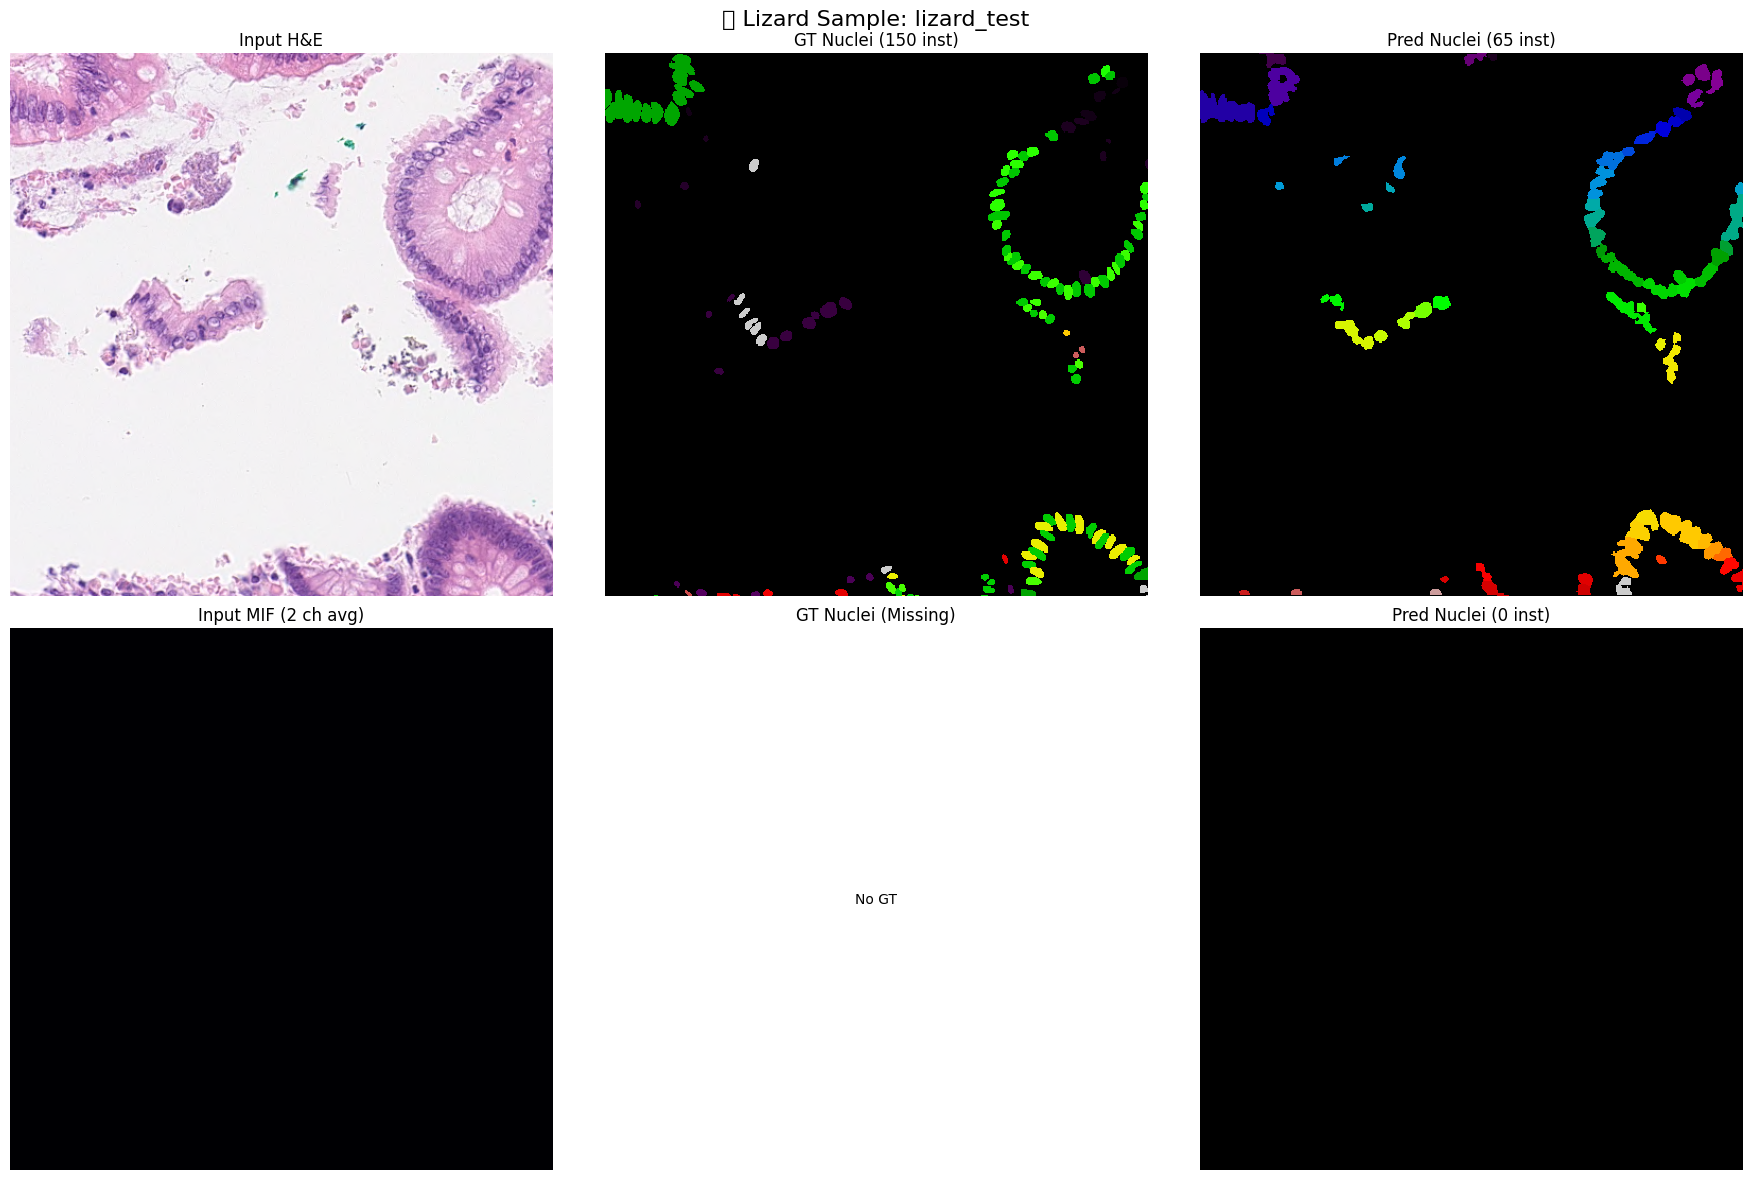


✅ Visualization generated.


In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
from metrics import get_fast_pq, aggregated_jaccard_index
from vitaminp import VitaminPFlex, SimplePreprocessing, prepare_he_input, prepare_mif_input
from postprocessing import process_model_outputs

# ==========================================
# 1. FIND LIZARD SAMPLES
# ==========================================
print("\n🦎 Finding Lizard samples...")
lizard_indices = []

# Search through dataset for lizard samples
# We'll check in batches to be efficient
batch_size = 100
for start_idx in range(0, len(test_dataset), batch_size):
    end_idx = min(start_idx + batch_size, len(test_dataset))
    for idx in range(start_idx, end_idx):
        sample = test_dataset[idx]
        if sample.get('dataset_source', '').lower() == 'lizard':
            lizard_indices.append(idx)
    
    # Stop early if we found enough
    if len(lizard_indices) > 20:
        print(f"Found {len(lizard_indices)} Lizard samples so far, stopping search...")
        break

print(f"✅ Found {len(lizard_indices)} Lizard samples total")

# ==========================================
# 2. HELPER FUNCTION: EXPLAINABLE METRICS
# ==========================================
def calculate_and_explain_pq(gt_map, pred_map, type_name="Nuclei"):
    """
    Calculates PQ with ZERO DIVISION PROTECTION.
    """
    gt_instances = np.unique(gt_map)
    gt_instances = gt_instances[gt_instances != 0]
    
    pred_instances = np.unique(pred_map)
    pred_instances = pred_instances[pred_instances != 0]

    # CHECK: If both are empty, skip
    if len(gt_instances) == 0 and len(pred_instances) == 0:
        print(f"\n⚠️ --- {type_name.upper()} SKIPPED ---")
        print("   Reason: Both Ground Truth and Prediction are empty (Missing Modality).")
        return 0.0, 0.0, 0.0

    # CHECK: If GT is empty but Prediction is not
    if len(gt_instances) == 0 and len(pred_instances) > 0:
        print(f"\n❌ --- {type_name.upper()} INVALID ---")
        print(f"   Reason: GT is empty, but model predicted {len(pred_instances)} instances (Pure False Positives).")
        return 0.0, 0.0, 0.0

    tp_count = 0
    iou_sum = 0
    matched_gt = set()
    matched_pred = set()

    for pred_id in pred_instances:
        pred_mask = (pred_map == pred_id)
        overlap_gt_ids = np.unique(gt_map[pred_mask])
        overlap_gt_ids = overlap_gt_ids[overlap_gt_ids != 0]
        
        best_iou = 0
        best_gt = None
        
        for gt_id in overlap_gt_ids:
            gt_mask = (gt_map == gt_id)
            intersection = np.logical_and(pred_mask, gt_mask).sum()
            union = np.logical_or(pred_mask, gt_mask).sum()
            iou = intersection / union
            
            if iou > 0.5 and iou > best_iou:
                best_iou = iou
                best_gt = gt_id
        
        if best_gt is not None and best_gt not in matched_gt:
            tp_count += 1
            iou_sum += best_iou
            matched_gt.add(best_gt)
            matched_pred.add(pred_id)

    fp_count = len(pred_instances) - len(matched_pred)
    fn_count = len(gt_instances) - len(matched_gt)

    denominator = tp_count + 0.5 * fp_count + 0.5 * fn_count
    dq = tp_count / denominator if denominator > 0 else 0.0
    sq = iou_sum / tp_count if tp_count > 0 else 0.0
    pq = sq * dq

    print(f"\n🔍 --- {type_name.upper()} METRIC EXPLANATION ---")
    print(f"  Ground Truth: {len(gt_instances)} | Predicted: {len(pred_instances)}")
    print(f"  TP: {tp_count} | FP: {fp_count} | FN: {fn_count}")
    print(f"  SQ: {sq:.4f} | DQ: {dq:.4f} | PQ: {pq:.4f}")
    
    return pq, dq, sq

# ==========================================
# 3. SELECT A RANDOM LIZARD SAMPLE
# ==========================================
if len(lizard_indices) == 0:
    print("❌ No Lizard samples found! Using random sample instead.")
    random_idx = random.randint(0, len(test_dataset) - 1)
else:
    random_idx = random.choice(lizard_indices)
    print(f"\n🎲 Selected Random Lizard Sample Index: {random_idx}")

sample = test_dataset[random_idx]
batch = torch.utils.data.default_collate([sample])
sample_name = batch['sample_name'][0]
dataset_source = batch['dataset_source'][0]
print(f"🖼️ Processing Sample: {sample_name} (Source: {dataset_source})")

# ==========================================
# 4. INFERENCE & VISUALIZATION
# ==========================================
with torch.no_grad():
    # --- PREPARE DATA ---
    he_img_raw = batch['he_image'].to(device)
    he_img = prepare_he_input(he_img_raw)
    he_img = preprocessor.percentile_normalize(he_img)
    
    mif_img_raw = batch['mif_image'].to(device)
    mif_img = prepare_mif_input(mif_img_raw)
    mif_img = preprocessor.percentile_normalize(mif_img)

    # --- RUN MODEL ---
    outputs_he = model(he_img)
    outputs_mif = model(mif_img)

    # --- POST PROCESSING ---
    # Helper to get prediction
    def get_pred(outputs, type_prefix):
        return process_model_outputs(
            outputs[f'{type_prefix}_seg'][0, 0].cpu().numpy(),
            outputs[f'{type_prefix}_hv'][0, 0].cpu().numpy(),
            outputs[f'{type_prefix}_hv'][0, 1].cpu().numpy()
        )[0]

    he_nuclei_pred = get_pred(outputs_he, 'he_nuclei')
    he_cell_pred = get_pred(outputs_he, 'he_cell')
    mif_nuclei_pred = get_pred(outputs_mif, 'mif_nuclei')
    mif_cell_pred = get_pred(outputs_mif, 'mif_cell')

    # Get GT
    he_nuclei_gt = batch['he_nuclei_instance'][0].cpu().numpy()
    he_cell_gt = batch['he_cell_instance'][0].cpu().numpy()
    mif_nuclei_gt = batch['mif_nuclei_instance'][0].cpu().numpy()
    mif_cell_gt = batch['mif_cell_instance'][0].cpu().numpy()

    # --- VERIFY METRICS ---
    print("\n" + "="*50)
    print("📊 METRIC VERIFICATION")
    print("="*50)
    
    calculate_and_explain_pq(he_nuclei_gt, he_nuclei_pred, "H&E Nuclei")
    calculate_and_explain_pq(he_cell_gt, he_cell_pred, "H&E Cells")
    calculate_and_explain_pq(mif_nuclei_gt, mif_nuclei_pred, "MIF Nuclei")
    calculate_and_explain_pq(mif_cell_gt, mif_cell_pred, "MIF Cells")

    # ==========================================
    # 5. ROBUST PLOTTING (FIXED)
    # ==========================================
    def to_plot(img_tensor):
        img = img_tensor[0].cpu().numpy().transpose(1, 2, 0)
        if img.max() > 1: img = img / 255.0
        return np.clip(img, 0, 1)

    # Prepare MIF display logic specifically for your error
    mif_raw_np = batch['mif_image'][0].cpu().numpy() # Shape: (C, H, W)
    C, H, W = mif_raw_np.shape
    
    if C == 3:
        # Perfect RGB
        mif_disp = mif_raw_np.transpose(1, 2, 0)
    elif C == 1:
        # Grayscale
        mif_disp = mif_raw_np[0]
    else:
        # If 2 channels, 4 channels, etc -> Average them to make a heatmap
        # This prevents the (H, W, 2) error
        print(f"\nℹ️ Note: MIF image has {C} channels. Collapsing to mean intensity for display.")
        mif_disp = np.mean(mif_raw_np, axis=0)

    # Check existence of GT
    has_he_nuc = he_nuclei_gt.max() > 0
    has_mif_nuc = mif_nuclei_gt.max() > 0
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    plt.suptitle(f"🦎 Lizard Sample: {sample_name}", fontsize=16)

    # --- ROW 1: H&E ---
    axes[0, 0].imshow(to_plot(batch['he_image']))
    axes[0, 0].set_title("Input H&E")
    
    if has_he_nuc:
        axes[0, 1].imshow(he_nuclei_gt, cmap='nipy_spectral', interpolation='nearest')
        axes[0, 1].set_title(f"GT Nuclei ({len(np.unique(he_nuclei_gt))-1} inst)")
    else:
        axes[0, 1].text(0.5, 0.5, "No GT", ha='center', va='center')
        axes[0, 1].set_title("GT Nuclei (Missing)")
        
    axes[0, 2].imshow(he_nuclei_pred, cmap='nipy_spectral', interpolation='nearest')
    axes[0, 2].set_title(f"Pred Nuclei ({len(np.unique(he_nuclei_pred))-1} inst)")

    # --- ROW 2: MIF ---
    axes[1, 0].imshow(mif_disp, cmap='magma')
    axes[1, 0].set_title(f"Input MIF ({C} ch avg)")
    
    if has_mif_nuc:
        axes[1, 1].imshow(mif_nuclei_gt, cmap='nipy_spectral', interpolation='nearest')
        axes[1, 1].set_title(f"GT Nuclei ({len(np.unique(mif_nuclei_gt))-1} inst)")
    else:
        axes[1, 1].text(0.5, 0.5, "No GT", ha='center', va='center')
        axes[1, 1].set_title("GT Nuclei (Missing)")
        
    axes[1, 2].imshow(mif_nuclei_pred, cmap='nipy_spectral', interpolation='nearest')
    axes[1, 2].set_title(f"Pred Nuclei ({len(np.unique(mif_nuclei_pred))-1} inst)")

    for ax in axes.flatten():
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print("\n✅ Visualization generated.")

🚀 Running Inference with TTA (3 views)...

📊 METRIC VERIFICATION (TTA ENABLED)

🔍 --- H&E NUCLEI METRIC EXPLANATION ---
  Ground Truth: 46 | Predicted: 26
  TP: 21 | FP: 5 | FN: 25
  SQ: 0.7105 | DQ: 0.5833 | PQ: 0.4145

❌ --- H&E CELLS INVALID ---
   Reason: GT is empty, but model predicted 48 instances (Pure False Positives).

⚠️ --- MIF NUCLEI SKIPPED ---
   Reason: Both Ground Truth and Prediction are empty (Missing Modality).

⚠️ --- MIF CELLS SKIPPED ---
   Reason: Both Ground Truth and Prediction are empty (Missing Modality).


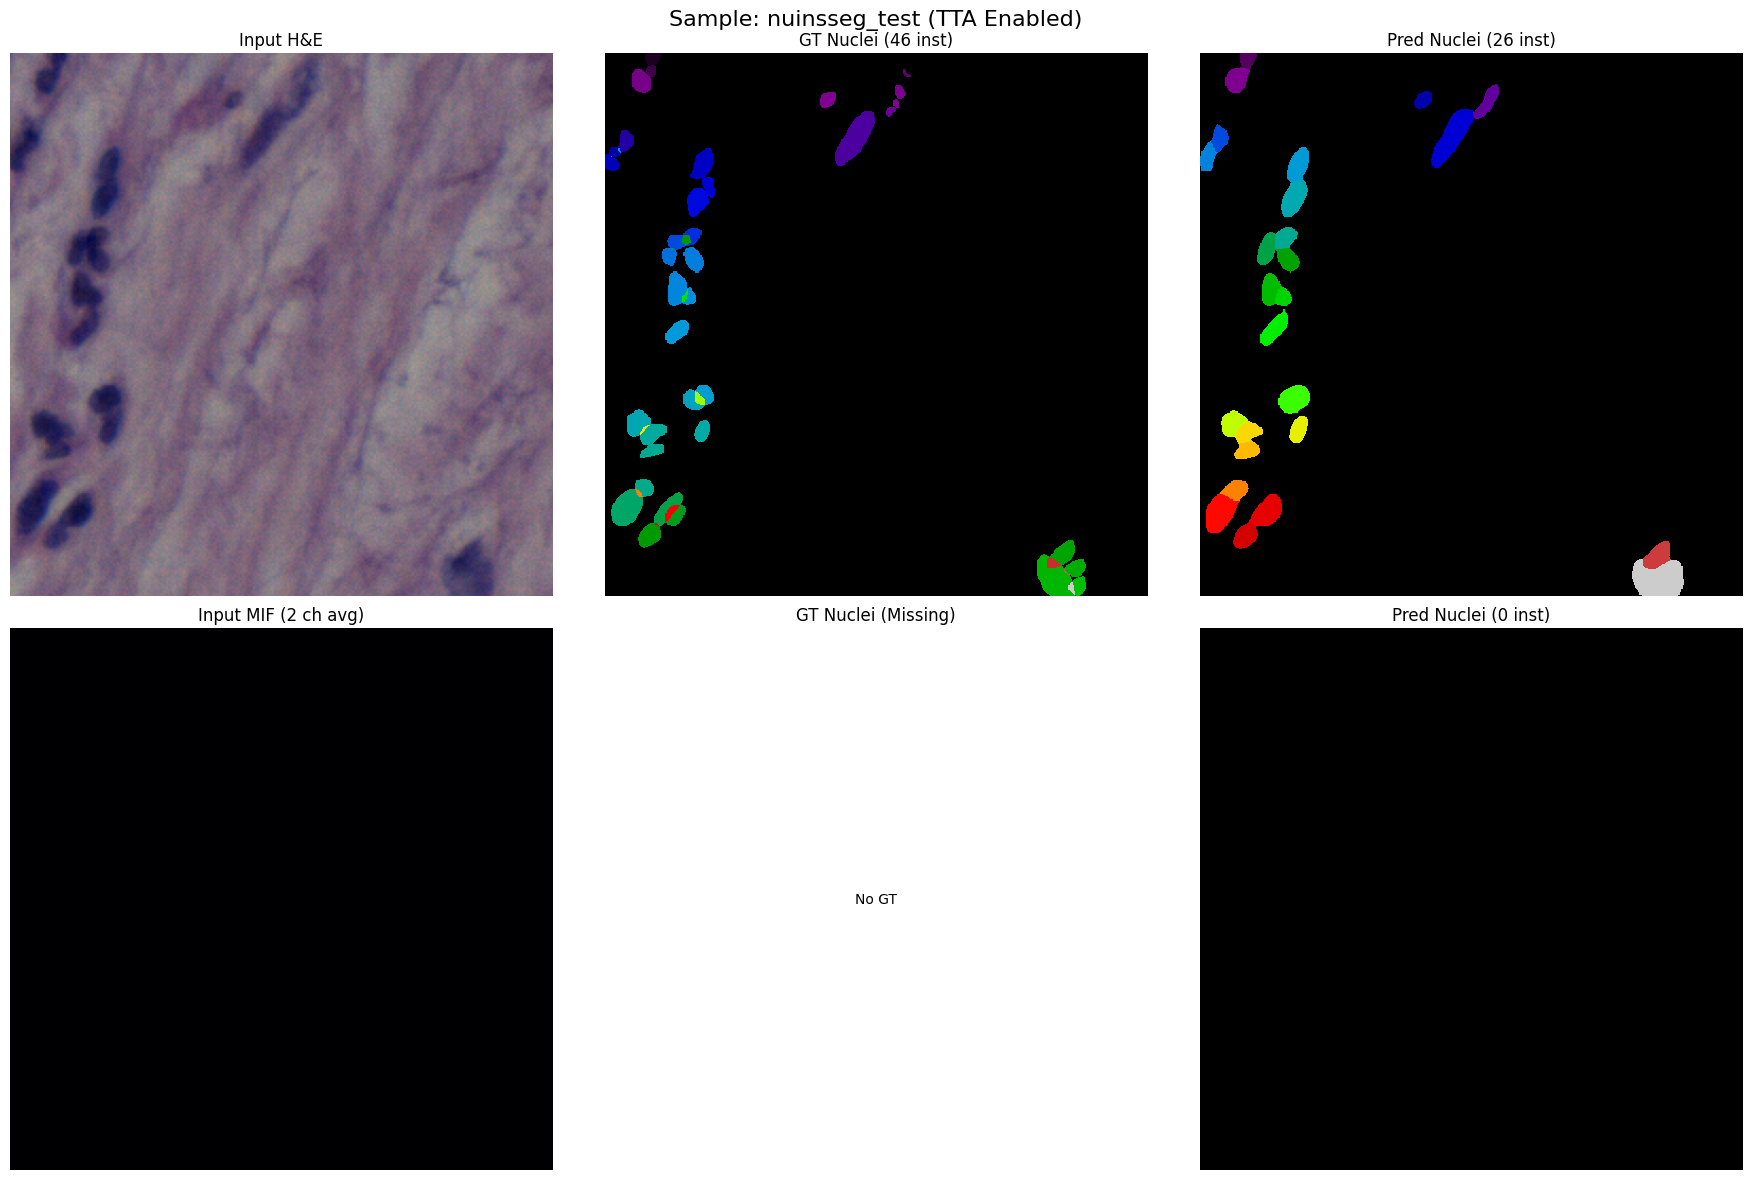


✅ Visualization generated.


In [15]:
# ==========================================
# 4. INFERENCE & VISUALIZATION (WITH TTA)
# ==========================================
def apply_tta(model, img_tensor):
    """
    Runs TTA (Original + HFlip + VFlip) and handles 
    geometric correction for HoVerMaps (HV).
    """
    model.eval()
    
    # --- Pass 1: Original ---
    out_orig = model(img_tensor)

    # --- Pass 2: Horizontal Flip ---
    # Flip input W dimension (idx 3)
    img_h = torch.flip(img_tensor, [3])
    out_h = model(img_h)
    
    # De-augment (Flip back)
    for k in out_h.keys():
        out_h[k] = torch.flip(out_h[k], [3]) # Spatial flip back
        # If this is an HV map, we must invert the Horizontal value (Channel 0)
        # Assumption: Channel 0 is X-gradient, Channel 1 is Y-gradient
        if 'hv' in k:
            out_h[k][:, 0, :, :] *= -1

    # --- Pass 3: Vertical Flip ---
    # Flip input H dimension (idx 2)
    img_v = torch.flip(img_tensor, [2])
    out_v = model(img_v)
    
    # De-augment
    for k in out_v.keys():
        out_v[k] = torch.flip(out_v[k], [2]) # Spatial flip back
        # If this is an HV map, we must invert the Vertical value (Channel 1)
        if 'hv' in k:
            out_v[k][:, 1, :, :] *= -1

    # --- Aggregate (Average) ---
    out_avg = {}
    for k in out_orig.keys():
        # Stack the 3 tensors and take the mean
        # We detach to save memory during inference
        stack = torch.stack([
            out_orig[k].detach(), 
            out_h[k].detach(), 
            out_v[k].detach()
        ])
        out_avg[k] = torch.mean(stack, dim=0)
        
    return out_avg

print("🚀 Running Inference with TTA (3 views)...")

with torch.no_grad():
    # --- PREPARE DATA ---
    he_img_raw = batch['he_image'].to(device)
    he_img = prepare_he_input(he_img_raw)
    he_img = preprocessor.percentile_normalize(he_img)
    
    mif_img_raw = batch['mif_image'].to(device)
    mif_img = prepare_mif_input(mif_img_raw)
    mif_img = preprocessor.percentile_normalize(mif_img)

    # --- RUN MODEL WITH TTA ---
    # Replaces standard model() call
    outputs_he = apply_tta(model, he_img)
    outputs_mif = apply_tta(model, mif_img)

    # --- POST PROCESSING (Same as before) ---
    def get_pred(outputs, type_prefix):
        return process_model_outputs(
            outputs[f'{type_prefix}_seg'][0, 0].cpu().numpy(),
            outputs[f'{type_prefix}_hv'][0, 0].cpu().numpy(),
            outputs[f'{type_prefix}_hv'][0, 1].cpu().numpy()
        )[0]

    he_nuclei_pred = get_pred(outputs_he, 'he_nuclei')
    he_cell_pred = get_pred(outputs_he, 'he_cell')
    mif_nuclei_pred = get_pred(outputs_mif, 'mif_nuclei')
    mif_cell_pred = get_pred(outputs_mif, 'mif_cell')

    # Get GT
    he_nuclei_gt = batch['he_nuclei_instance'][0].cpu().numpy()
    he_cell_gt = batch['he_cell_instance'][0].cpu().numpy()
    mif_nuclei_gt = batch['mif_nuclei_instance'][0].cpu().numpy()
    mif_cell_gt = batch['mif_cell_instance'][0].cpu().numpy()

    # --- VERIFY METRICS ---
    print("\n" + "="*50)
    print("📊 METRIC VERIFICATION (TTA ENABLED)")
    print("="*50)
    
    calculate_and_explain_pq(he_nuclei_gt, he_nuclei_pred, "H&E Nuclei")
    calculate_and_explain_pq(he_cell_gt, he_cell_pred, "H&E Cells")
    calculate_and_explain_pq(mif_nuclei_gt, mif_nuclei_pred, "MIF Nuclei")
    calculate_and_explain_pq(mif_cell_gt, mif_cell_pred, "MIF Cells")

    # ==========================================
    # 5. ROBUST PLOTTING (FIXED)
    # ==========================================
    def to_plot(img_tensor):
        img = img_tensor[0].cpu().numpy().transpose(1, 2, 0)
        if img.max() > 1: img = img / 255.0
        return np.clip(img, 0, 1)

    # Prepare MIF display logic
    mif_raw_np = batch['mif_image'][0].cpu().numpy() 
    C, H, W = mif_raw_np.shape
    
    if C == 3:
        mif_disp = mif_raw_np.transpose(1, 2, 0)
    elif C == 1:
        mif_disp = mif_raw_np[0]
    else:
        mif_disp = np.mean(mif_raw_np, axis=0)

    # Check existence of GT
    has_he_nuc = he_nuclei_gt.max() > 0
    has_mif_nuc = mif_nuclei_gt.max() > 0
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    plt.suptitle(f"Sample: {sample_name} (TTA Enabled)", fontsize=16)

    # --- ROW 1: H&E ---
    axes[0, 0].imshow(to_plot(batch['he_image']))
    axes[0, 0].set_title("Input H&E")
    
    if has_he_nuc:
        axes[0, 1].imshow(he_nuclei_gt, cmap='nipy_spectral', interpolation='nearest')
        axes[0, 1].set_title(f"GT Nuclei ({len(np.unique(he_nuclei_gt))-1} inst)")
    else:
        axes[0, 1].text(0.5, 0.5, "No GT", ha='center', va='center')
        axes[0, 1].set_title("GT Nuclei (Missing)")
        
    axes[0, 2].imshow(he_nuclei_pred, cmap='nipy_spectral', interpolation='nearest')
    axes[0, 2].set_title(f"Pred Nuclei ({len(np.unique(he_nuclei_pred))-1} inst)")

    # --- ROW 2: MIF ---
    axes[1, 0].imshow(mif_disp, cmap='magma')
    axes[1, 0].set_title(f"Input MIF ({C} ch avg)")
    
    if has_mif_nuc:
        axes[1, 1].imshow(mif_nuclei_gt, cmap='nipy_spectral', interpolation='nearest')
        axes[1, 1].set_title(f"GT Nuclei ({len(np.unique(mif_nuclei_gt))-1} inst)")
    else:
        axes[1, 1].text(0.5, 0.5, "No GT", ha='center', va='center')
        axes[1, 1].set_title("GT Nuclei (Missing)")
        
    axes[1, 2].imshow(mif_nuclei_pred, cmap='nipy_spectral', interpolation='nearest')
    axes[1, 2].set_title(f"Pred Nuclei ({len(np.unique(mif_nuclei_pred))-1} inst)")

    for ax in axes.flatten():
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print("\n✅ Visualization generated.")

## Whole dataset

In [7]:
import torch
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from metrics import get_fast_pq, aggregated_jaccard_index
from vitaminp import VitaminPFlex, SimplePreprocessing, prepare_he_input, prepare_mif_input
from postprocessing import process_model_outputs

# ==========================================
# 1. CONFIGURATION
# ==========================================
TARGET_DATASET = 'tnbc_test'  # The key you want to use from DATASET_MODALITIES

DATASET_MODALITIES = {
    'pannuke_test': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': False, 'mif_cell': False},
    'tissuenet_test': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': False, 'mif_cell': False},
    'lizard_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'monuseg_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'tnbc_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'nuinsseg_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'cryonuseg_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'bc_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'consep_test': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': False, 'mif_cell': False},
    'monusac_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'kumar_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'cpm17_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'CRC03': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': True, 'mif_cell': True},
    'CRC11': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': True, 'mif_cell': True},
    'CRC37': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': True, 'mif_cell': True},
}

# ==========================================
# 2. SETUP & HELPER FUNCTIONS
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("\n📦 Loading model...")
model = VitaminPFlex(model_size='large').to(device)
checkpoint_path = "checkpoints/vitamin_p_flex_large_fold32_hv4_test_best.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
preprocessor = SimplePreprocessing()
print(f"✅ Model loaded")

def normalize_name(name):
    """Normalize dataset names to ensure matching works."""
    # Convert to string, lowercase, strip whitespace, remove '_test' suffix for comparison
    s = str(name).lower().strip()
    return s.replace('_test', '')

target_normalized = normalize_name(TARGET_DATASET)
print(f"\n🎯 Target Dataset: '{TARGET_DATASET}' (Normalized check: '{target_normalized}')")

metrics_storage = defaultdict(list)
tile_count = 0
seen_sources = set()

# ==========================================
# 3. EVALUATION LOOP
# ==========================================
print(f"🚀 Starting evaluation...")

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_loader, desc=f"Scanning Batches")):
        
        # --- 3a. Robust Filtering ---
        batch_sources = batch.get('dataset_source', [])
        
        target_indices = []
        for i, source in enumerate(batch_sources):
            # Log unique sources encountered for debugging
            if source not in seen_sources:
                seen_sources.add(source)
                # print(f"\n   Found new source: '{source}'") # Uncomment if you want to see them as they appear
            
            # Normalize and compare
            src_norm = normalize_name(source)
            
            # Match if normalized names are same OR if one is substring of other
            if src_norm == target_normalized or target_normalized in src_norm:
                target_indices.append(i)
        
        if not target_indices:
            continue

        tile_count += len(target_indices)

        # --- 3b. Prepare Inputs ---
        he_img = prepare_he_input(batch['he_image'].to(device))
        he_img = preprocessor.percentile_normalize(he_img)
        
        # Only prepare MIF if needed (save compute)
        has_mif = DATASET_MODALITIES[TARGET_DATASET]['mif_nuclei'] or DATASET_MODALITIES[TARGET_DATASET]['mif_cell']
        if has_mif:
            mif_img = prepare_mif_input(batch['mif_image'].to(device))
            mif_img = preprocessor.percentile_normalize(mif_img)
        
        # Run Inference
        outputs_he = model(he_img)
        outputs_mif = model(mif_img) if has_mif else None

        # --- 3c. Calculate Metrics ---
        for i in target_indices:
            
            # H&E NUCLEI
            if DATASET_MODALITIES[TARGET_DATASET]['he_nuclei']:
                pred, _, _ = process_model_outputs(
                    outputs_he['he_nuclei_seg'][i, 0].cpu().numpy(),
                    outputs_he['he_nuclei_hv'][i, 0].cpu().numpy(),
                    outputs_he['he_nuclei_hv'][i, 1].cpu().numpy()
                )
                gt = batch['he_nuclei_instance'][i].cpu().numpy()
                if gt.max() > 0: # Only calc if GT exists
                    pq, dq, sq = get_fast_pq(gt, pred)
                    aji = aggregated_jaccard_index(gt, pred)
                    metrics_storage['he_nuclei_pq'].append(pq)
                    metrics_storage['he_nuclei_dq'].append(dq)
                    metrics_storage['he_nuclei_sq'].append(sq)
                    metrics_storage['he_nuclei_aji'].append(aji)

            # H&E CELL
            if DATASET_MODALITIES[TARGET_DATASET]['he_cell']:
                pred, _, _ = process_model_outputs(
                    outputs_he['he_cell_seg'][i, 0].cpu().numpy(),
                    outputs_he['he_cell_hv'][i, 0].cpu().numpy(),
                    outputs_he['he_cell_hv'][i, 1].cpu().numpy()
                )
                gt = batch['he_cell_instance'][i].cpu().numpy()
                if gt.max() > 0:
                    pq, dq, sq = get_fast_pq(gt, pred)
                    aji = aggregated_jaccard_index(gt, pred)
                    metrics_storage['he_cell_pq'].append(pq)
                    metrics_storage['he_cell_dq'].append(dq)
                    metrics_storage['he_cell_sq'].append(sq)
                    metrics_storage['he_cell_aji'].append(aji)

            # MIF NUCLEI
            if DATASET_MODALITIES[TARGET_DATASET]['mif_nuclei'] and outputs_mif:
                pred, _, _ = process_model_outputs(
                    outputs_mif['mif_nuclei_seg'][i, 0].cpu().numpy(),
                    outputs_mif['mif_nuclei_hv'][i, 0].cpu().numpy(),
                    outputs_mif['mif_nuclei_hv'][i, 1].cpu().numpy()
                )
                gt = batch['mif_nuclei_instance'][i].cpu().numpy()
                if gt.max() > 0:
                    pq, dq, sq = get_fast_pq(gt, pred)
                    aji = aggregated_jaccard_index(gt, pred)
                    metrics_storage['mif_nuclei_pq'].append(pq)
                    metrics_storage['mif_nuclei_dq'].append(dq)
                    metrics_storage['mif_nuclei_sq'].append(sq)
                    metrics_storage['mif_nuclei_aji'].append(aji)

            # MIF CELL
            if DATASET_MODALITIES[TARGET_DATASET]['mif_cell'] and outputs_mif:
                pred, _, _ = process_model_outputs(
                    outputs_mif['mif_cell_seg'][i, 0].cpu().numpy(),
                    outputs_mif['mif_cell_hv'][i, 0].cpu().numpy(),
                    outputs_mif['mif_cell_hv'][i, 1].cpu().numpy()
                )
                gt = batch['mif_cell_instance'][i].cpu().numpy()
                if gt.max() > 0:
                    pq, dq, sq = get_fast_pq(gt, pred)
                    aji = aggregated_jaccard_index(gt, pred)
                    metrics_storage['mif_cell_pq'].append(pq)
                    metrics_storage['mif_cell_dq'].append(dq)
                    metrics_storage['mif_cell_sq'].append(sq)
                    metrics_storage['mif_cell_aji'].append(aji)

# ==========================================
# 4. REPORTING
# ==========================================
print("\n" + "="*80)
print(f"📊 EVALUATION REPORT: {TARGET_DATASET}")
print(f"   Total Matching Tiles: {tile_count}")
print(f"   Seen Dataset Sources in Loader: {seen_sources}")
print("="*80)

def get_stats(key_prefix):
    if len(metrics_storage[f'{key_prefix}_pq']) == 0:
        return None
    return {
        'pq': np.mean(metrics_storage[f'{key_prefix}_pq']),
        'dq': np.mean(metrics_storage[f'{key_prefix}_dq']),
        'sq': np.mean(metrics_storage[f'{key_prefix}_sq']),
        'aji': np.mean(metrics_storage[f'{key_prefix}_aji']),
        'count': len(metrics_storage[f'{key_prefix}_pq'])
    }

print(f"{'Modality':<20} | {'Count':<6} | {'PQ':<8} | {'DQ':<8} | {'SQ':<8} | {'AJI':<8}")
print("-" * 80)

modalities_to_print = [
    ('H&E Nuclei', 'he_nuclei'),
    ('H&E Cells', 'he_cell'),
    ('MIF Nuclei', 'mif_nuclei'),
    ('MIF Cells', 'mif_cell'),
]

for label, key in modalities_to_print:
    stats = get_stats(key)
    if stats:
        print(f"{label:<20} | {stats['count']:<6} | {stats['pq']:.4f}   | {stats['dq']:.4f}   | {stats['sq']:.4f}   | {stats['aji']:.4f}")
    else:
        print(f"{label:<20} | {'0':<6} | {'N/A':<8} | {'N/A':<8} | {'N/A':<8} | {'N/A':<8}")

print("-" * 80)

Using device: cuda

📦 Loading model...
✓ VitaminPFlex initialized with large backbone
  Architecture: Shared Encoder → 4 Separate Decoders
  Embed dim: 1024 | Decoder dims: [1024, 512, 256, 128]
✅ Model loaded

🎯 Target Dataset: 'tnbc_test' (Normalized check: 'tnbc')
🚀 Starting evaluation...


Scanning Batches: 100%|██████████| 488/488 [01:46<00:00,  4.58it/s]


📊 EVALUATION REPORT: tnbc_test
   Total Matching Tiles: 7
   Seen Dataset Sources in Loader: {'cryonuseg', 'tissuenet', 'monusac', 'nuinsseg', 'crc', 'bc', 'kumar', 'monuseg', 'cpm17', 'lizard', 'consep', 'pannuke', 'tnbc'}
Modality             | Count  | PQ       | DQ       | SQ       | AJI     
--------------------------------------------------------------------------------
H&E Nuclei           | 7      | 0.6382   | 0.8133   | 0.7800   | 0.6662
H&E Cells            | 0      | N/A      | N/A      | N/A      | N/A     
MIF Nuclei           | 0      | N/A      | N/A      | N/A      | N/A     
MIF Cells            | 0      | N/A      | N/A      | N/A      | N/A     
--------------------------------------------------------------------------------


In [21]:
import torch
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from metrics import get_fast_pq, aggregated_jaccard_index
from vitaminp import VitaminPFlex, SimplePreprocessing, prepare_he_input, prepare_mif_input
from postprocessing import process_model_outputs

# ==========================================
# 1. CONFIGURATION
# ==========================================
TARGET_DATASET = 'pannuke_test'  # The key you want to use from DATASET_MODALITIES

DATASET_MODALITIES = {
    'pannuke_test': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': False, 'mif_cell': False},
    'tissuenet_test': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': False, 'mif_cell': False},
    'lizard_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'monuseg_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'tnbc_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'nuinsseg_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'cryonuseg_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'bc_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'consep_test': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': False, 'mif_cell': False},
    'monusac_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'kumar_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'cpm17_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'CRC03': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': True, 'mif_cell': True},
    'CRC11': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': True, 'mif_cell': True},
    'CRC37': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': True, 'mif_cell': True},
}

# ==========================================
# 2. SETUP & HELPER FUNCTIONS
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("\n📦 Loading model...")
model = VitaminPFlex(model_size='large').to(device)
checkpoint_path = "checkpoints/vitamin_p_flex_large_fold32_hv4_best.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
preprocessor = SimplePreprocessing()
print(f"✅ Model loaded")

def normalize_name(name):
    """Normalize dataset names to ensure matching works."""
    s = str(name).lower().strip()
    return s.replace('_test', '')

target_normalized = normalize_name(TARGET_DATASET)
print(f"\n🎯 Target Dataset: '{TARGET_DATASET}' (Normalized check: '{target_normalized}')")

# --- Metric Storage (Separate for Base and TTA) ---
metrics_base = defaultdict(list)
metrics_tta = defaultdict(list)

tile_count = 0
seen_sources = set()

def get_tta_outputs(model, img_tensor):
    """
    Runs inference and returns TWO dictionaries:
    1. out_orig: The standard single-pass output.
    2. out_avg: The averaged TTA output (Original + HFlip + VFlip).
    """
    # --- Pass 1: Original ---
    out_orig = model(img_tensor)

    # --- Pass 2: Horizontal Flip ---
    img_h = torch.flip(img_tensor, [3])
    out_h = model(img_h)
    
    # De-augment H
    for k in out_h.keys():
        out_h[k] = torch.flip(out_h[k], [3])
        if 'hv' in k: # Invert X-gradient (Channel 0)
            out_h[k][:, 0, :, :] *= -1

    # --- Pass 3: Vertical Flip ---
    img_v = torch.flip(img_tensor, [2])
    out_v = model(img_v)
    
    # De-augment V
    for k in out_v.keys():
        out_v[k] = torch.flip(out_v[k], [2])
        if 'hv' in k: # Invert Y-gradient (Channel 1)
            out_v[k][:, 1, :, :] *= -1

    # --- Aggregate ---
    out_avg = {}
    for k in out_orig.keys():
        stack = torch.stack([out_orig[k], out_h[k], out_v[k]])
        out_avg[k] = torch.mean(stack, dim=0)
        
    return out_orig, out_avg

# ==========================================
# 3. EVALUATION LOOP
# ==========================================
print(f"🚀 Starting evaluation (Comparing Base vs. TTA)...")

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_loader, desc=f"Scanning Batches")):
        
        # --- 3a. Robust Filtering ---
        batch_sources = batch.get('dataset_source', [])
        target_indices = []
        for i, source in enumerate(batch_sources):
            if source not in seen_sources:
                seen_sources.add(source)
            src_norm = normalize_name(source)
            if src_norm == target_normalized or target_normalized in src_norm:
                target_indices.append(i)
        
        if not target_indices:
            continue

        tile_count += len(target_indices)

        # --- 3b. Prepare Inputs ---
        he_img = prepare_he_input(batch['he_image'].to(device))
        he_img = preprocessor.percentile_normalize(he_img)
        
        has_mif = DATASET_MODALITIES[TARGET_DATASET]['mif_nuclei'] or DATASET_MODALITIES[TARGET_DATASET]['mif_cell']
        if has_mif:
            mif_img = prepare_mif_input(batch['mif_image'].to(device))
            mif_img = preprocessor.percentile_normalize(mif_img)
        
        # --- Run Inference (With TTA logic) ---
        # Get BOTH original and TTA averaged outputs
        out_he_base, out_he_tta = get_tta_outputs(model, he_img)
        
        out_mif_base, out_mif_tta = (None, None)
        if has_mif:
            out_mif_base, out_mif_tta = get_tta_outputs(model, mif_img)

        # --- 3c. Calculate Metrics for BOTH ---
        for i in target_indices:
            
            # Helper to calculate and store
            def process_and_store(outputs, prefix, metric_dict):
                if not outputs: return
                
                # NUCLEI
                if DATASET_MODALITIES[TARGET_DATASET][f'{prefix}_nuclei']:
                    pred, _, _ = process_model_outputs(
                        outputs[f'{prefix}_nuclei_seg'][i, 0].cpu().numpy(),
                        outputs[f'{prefix}_nuclei_hv'][i, 0].cpu().numpy(),
                        outputs[f'{prefix}_nuclei_hv'][i, 1].cpu().numpy()
                    )
                    gt = batch[f'{prefix}_nuclei_instance'][i].cpu().numpy()
                    if gt.max() > 0:
                        pq, dq, sq = get_fast_pq(gt, pred)
                        aji = aggregated_jaccard_index(gt, pred)
                        metric_dict[f'{prefix}_nuclei_pq'].append(pq)
                        metric_dict[f'{prefix}_nuclei_dq'].append(dq)
                        metric_dict[f'{prefix}_nuclei_sq'].append(sq)
                        metric_dict[f'{prefix}_nuclei_aji'].append(aji)

                # CELL
                if DATASET_MODALITIES[TARGET_DATASET][f'{prefix}_cell']:
                    pred, _, _ = process_model_outputs(
                        outputs[f'{prefix}_cell_seg'][i, 0].cpu().numpy(),
                        outputs[f'{prefix}_cell_hv'][i, 0].cpu().numpy(),
                        outputs[f'{prefix}_cell_hv'][i, 1].cpu().numpy()
                    )
                    gt = batch[f'{prefix}_cell_instance'][i].cpu().numpy()
                    if gt.max() > 0:
                        pq, dq, sq = get_fast_pq(gt, pred)
                        aji = aggregated_jaccard_index(gt, pred)
                        metric_dict[f'{prefix}_cell_pq'].append(pq)
                        metric_dict[f'{prefix}_cell_dq'].append(dq)
                        metric_dict[f'{prefix}_cell_sq'].append(sq)
                        metric_dict[f'{prefix}_cell_aji'].append(aji)

            # Store Base Metrics
            process_and_store(out_he_base, 'he', metrics_base)
            process_and_store(out_mif_base, 'mif', metrics_base)
            
            # Store TTA Metrics
            process_and_store(out_he_tta, 'he', metrics_tta)
            process_and_store(out_mif_tta, 'mif', metrics_tta)

# ==========================================
# 4. REPORTING
# ==========================================
print("\n" + "="*95)
print(f"📊 COMPARATIVE EVALUATION REPORT: {TARGET_DATASET}")
print(f"   Total Matching Tiles: {tile_count}")
print(f"   Seen Dataset Sources: {seen_sources}")
print("="*95)

# Helper to print comparative row
def print_comparison(label, key):
    # Check if we have data
    if len(metrics_base[f'{key}_pq']) == 0:
        return

    # Calculate Means
    base_pq = np.mean(metrics_base[f'{key}_pq'])
    tta_pq = np.mean(metrics_tta[f'{key}_pq'])
    
    base_aji = np.mean(metrics_base[f'{key}_aji'])
    tta_aji = np.mean(metrics_tta[f'{key}_aji'])
    
    # Calculate Deltas
    delta_pq = tta_pq - base_pq
    delta_aji = tta_aji - base_aji
    
    # Define symbols
    pq_sym = "🔺" if delta_pq > 0 else "🔻"
    aji_sym = "🔺" if delta_aji > 0 else "🔻"

    print(f"➡️  {label}")
    print(f"   {'Metric':<10} | {'Base':<10} | {'TTA':<10} | {'Improvement':<15}")
    print(f"   {'-'*55}")
    print(f"   {'PQ':<10} | {base_pq:.4f}     | {tta_pq:.4f}     | {pq_sym} {delta_pq:+.4f}")
    print(f"   {'AJI':<10} | {base_aji:.4f}    | {tta_aji:.4f}    | {aji_sym} {delta_aji:+.4f}")
    print(f"   {'-'*55}\n")

modalities_to_print = [
    ('H&E Nuclei', 'he_nuclei'),
    ('H&E Cells', 'he_cell'),
    ('MIF Nuclei', 'mif_nuclei'),
    ('MIF Cells', 'mif_cell'),
]

found_any = False
for label, key in modalities_to_print:
    if len(metrics_base[f'{key}_pq']) > 0:
        found_any = True
        print_comparison(label, key)

if not found_any:
    print("⚠️ No relevant metrics found for this dataset config.")

print("="*95)

Using device: cuda

📦 Loading model...
✓ VitaminPFlex initialized with large backbone
  Architecture: Shared Encoder → 4 Separate Decoders
  Embed dim: 1024 | Decoder dims: [1024, 512, 256, 128]
✅ Model loaded

🎯 Target Dataset: 'pannuke_test' (Normalized check: 'pannuke')
🚀 Starting evaluation (Comparing Base vs. TTA)...


Scanning Batches: 100%|██████████| 488/488 [09:49<00:00,  1.21s/it]


📊 COMPARATIVE EVALUATION REPORT: pannuke_test
   Total Matching Tiles: 681
   Seen Dataset Sources: {'cryonuseg', 'tissuenet', 'monusac', 'nuinsseg', 'crc', 'bc', 'kumar', 'monuseg', 'cpm17', 'lizard', 'consep', 'pannuke', 'tnbc'}
➡️  H&E Nuclei
   Metric     | Base       | TTA        | Improvement    
   -------------------------------------------------------
   PQ         | 0.6352     | 0.6447     | 🔺 +0.0095
   AJI        | 0.6600    | 0.6673    | 🔺 +0.0073
   -------------------------------------------------------



In [4]:
import torch
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from metrics import get_fast_pq, aggregated_jaccard_index
from vitaminp import VitaminPFlex, SimplePreprocessing, prepare_he_input, prepare_mif_input
from postprocessing import process_model_outputs

# ==========================================
# 1. CONFIGURATION: DATASET MODALITIES
# ==========================================
# Mapping strict names found in your loader to their valid modalities
DATASET_MODALITIES = {
    'pannuke':   {'he_nuclei': True, 'he_cell': True,  'mif_nuclei': False, 'mif_cell': False},
    'tissuenet': {'he_nuclei': True, 'he_cell': True,  'mif_nuclei': False, 'mif_cell': False},
    'lizard':    {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'monuseg':   {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'tnbc':      {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'nuinsseg':  {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'cryonuseg': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'bc':        {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'consep':    {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False}, # Typically nuclei only
    'monusac':   {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'kumar':     {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'cpm17':     {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'crc':       {'he_nuclei': True, 'he_cell': True,  'mif_nuclei': True,  'mif_cell': True},  # Combined CRC
}

# ==========================================
# 2. SETUP
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("\n📦 Loading model...")
model = VitaminPFlex(model_size='large').to(device)
checkpoint_path = "checkpoints/vitamin_p_flex_large_fold32_hv4_test_best.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
preprocessor = SimplePreprocessing()
print(f"✅ Model loaded")

# Storage: metrics[dataset_name][modality_metric] -> list of values
# Example: metrics['kumar']['he_nuclei_pq'] = [0.65, 0.70, ...]
dataset_metrics = defaultdict(lambda: defaultdict(list))
dataset_counts = defaultdict(int)

# ==========================================
# 3. EVALUATION LOOP
# ==========================================
print("\n🚀 Starting Global Evaluation...")

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Processing Test Set"):
        
        # Get batch sources
        sources = batch.get('dataset_source', [])
        
        # Prepare inputs once per batch
        he_img = prepare_he_input(batch['he_image'].to(device))
        he_img = preprocessor.percentile_normalize(he_img)
        
        # Prepare MIF only if *any* sample in batch is CRC (optimization)
        has_mif_in_batch = any(s == 'crc' for s in sources)
        if has_mif_in_batch:
            mif_img = prepare_mif_input(batch['mif_image'].to(device))
            mif_img = preprocessor.percentile_normalize(mif_img)
        else:
            mif_img = None

        # Run Inference
        outputs_he = model(he_img)
        outputs_mif = model(mif_img) if has_mif_in_batch else None

        # Iterate through samples in batch
        batch_size = len(sources)
        for i in range(batch_size):
            ds_name = sources[i]
            
            # Skip unknown datasets not in our config
            if ds_name not in DATASET_MODALITIES:
                continue
                
            dataset_counts[ds_name] += 1
            mods = DATASET_MODALITIES[ds_name]

            # --- H&E NUCLEI ---
            if mods['he_nuclei']:
                pred, _, _ = process_model_outputs(
                    outputs_he['he_nuclei_seg'][i, 0].cpu().numpy(),
                    outputs_he['he_nuclei_hv'][i, 0].cpu().numpy(),
                    outputs_he['he_nuclei_hv'][i, 1].cpu().numpy()
                )
                gt = batch['he_nuclei_instance'][i].cpu().numpy()
                if gt.max() > 0: # Check if GT is not empty
                    pq, dq, sq = get_fast_pq(gt, pred)
                    aji = aggregated_jaccard_index(gt, pred)
                    dataset_metrics[ds_name]['he_nuclei_pq'].append(pq)
                    dataset_metrics[ds_name]['he_nuclei_dq'].append(dq)
                    dataset_metrics[ds_name]['he_nuclei_sq'].append(sq)
                    dataset_metrics[ds_name]['he_nuclei_aji'].append(aji)

            # --- H&E CELLS ---
            if mods['he_cell']:
                pred, _, _ = process_model_outputs(
                    outputs_he['he_cell_seg'][i, 0].cpu().numpy(),
                    outputs_he['he_cell_hv'][i, 0].cpu().numpy(),
                    outputs_he['he_cell_hv'][i, 1].cpu().numpy()
                )
                gt = batch['he_cell_instance'][i].cpu().numpy()
                if gt.max() > 0:
                    pq, dq, sq = get_fast_pq(gt, pred)
                    aji = aggregated_jaccard_index(gt, pred)
                    dataset_metrics[ds_name]['he_cell_pq'].append(pq)
                    dataset_metrics[ds_name]['he_cell_dq'].append(dq)
                    dataset_metrics[ds_name]['he_cell_sq'].append(sq)
                    dataset_metrics[ds_name]['he_cell_aji'].append(aji)

            # --- MIF NUCLEI (Only if outputs_mif exists and modality is True) ---
            if mods['mif_nuclei'] and outputs_mif is not None:
                pred, _, _ = process_model_outputs(
                    outputs_mif['mif_nuclei_seg'][i, 0].cpu().numpy(),
                    outputs_mif['mif_nuclei_hv'][i, 0].cpu().numpy(),
                    outputs_mif['mif_nuclei_hv'][i, 1].cpu().numpy()
                )
                gt = batch['mif_nuclei_instance'][i].cpu().numpy()
                if gt.max() > 0:
                    pq, dq, sq = get_fast_pq(gt, pred)
                    aji = aggregated_jaccard_index(gt, pred)
                    dataset_metrics[ds_name]['mif_nuclei_pq'].append(pq)
                    dataset_metrics[ds_name]['mif_nuclei_dq'].append(dq)
                    dataset_metrics[ds_name]['mif_nuclei_sq'].append(sq)
                    dataset_metrics[ds_name]['mif_nuclei_aji'].append(aji)

            # --- MIF CELLS ---
            if mods['mif_cell'] and outputs_mif is not None:
                pred, _, _ = process_model_outputs(
                    outputs_mif['mif_cell_seg'][i, 0].cpu().numpy(),
                    outputs_mif['mif_cell_hv'][i, 0].cpu().numpy(),
                    outputs_mif['mif_cell_hv'][i, 1].cpu().numpy()
                )
                gt = batch['mif_cell_instance'][i].cpu().numpy()
                if gt.max() > 0:
                    pq, dq, sq = get_fast_pq(gt, pred)
                    aji = aggregated_jaccard_index(gt, pred)
                    dataset_metrics[ds_name]['mif_cell_pq'].append(pq)
                    dataset_metrics[ds_name]['mif_cell_dq'].append(dq)
                    dataset_metrics[ds_name]['mif_cell_sq'].append(sq)
                    dataset_metrics[ds_name]['mif_cell_aji'].append(aji)

# ==========================================
# 4. PRINT TABLES FOR ALL DATASETS
# ==========================================
print("\n" + "="*80)
print("📊 FINAL EVALUATION REPORT - PER DATASET")
print("="*80)

# Sort datasets alphabetically for clean output
sorted_datasets = sorted(dataset_metrics.keys())

for ds_name in sorted_datasets:
    count = dataset_counts[ds_name]
    metrics = dataset_metrics[ds_name]
    
    print(f"\n📁 DATASET: {ds_name.upper()} (Tiles: {count})")
    print(f"{'Modality':<20} | {'PQ':<8} | {'DQ':<8} | {'SQ':<8} | {'AJI':<8}")
    print("-" * 65)
    
    # List of modalities to check
    check_list = [
        ('H&E Nuclei', 'he_nuclei'),
        ('H&E Cells',  'he_cell'),
        ('MIF Nuclei', 'mif_nuclei'),
        ('MIF Cells',  'mif_cell')
    ]
    
    for label, key in check_list:
        # Check if we have data for this metric
        pq_list = metrics.get(f'{key}_pq', [])
        
        if len(pq_list) > 0:
            pq_mean = np.mean(pq_list)
            dq_mean = np.mean(metrics[f'{key}_dq'])
            sq_mean = np.mean(metrics[f'{key}_sq'])
            aji_mean = np.mean(metrics[f'{key}_aji'])
            
            print(f"{label:<20} | {pq_mean:.4f}   | {dq_mean:.4f}   | {sq_mean:.4f}   | {aji_mean:.4f}")
        else:
            # If modality is theoretically supported but no samples had GT, or not supported
            status = "N/A"
            print(f"{label:<20} | {status:<8} | {status:<8} | {status:<8} | {status:<8}")
    
    print("-" * 65)

print("\n✅ All datasets processed.")

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda

📦 Loading model...
✓ VitaminPFlex initialized with large backbone
  Architecture: Shared Encoder → 4 Separate Decoders
  Embed dim: 1024 | Decoder dims: [1024, 512, 256, 128]
✅ Model loaded

🚀 Starting Global Evaluation...


Processing Test Set: 100%|██████████| 488/488 [15:01<00:00,  1.85s/it]


📊 FINAL EVALUATION REPORT - PER DATASET

📁 DATASET: BC (Tiles: 66)
Modality             | PQ       | DQ       | SQ       | AJI     
-----------------------------------------------------------------
H&E Nuclei           | 0.5828   | 0.7652   | 0.7584   | 0.6551
H&E Cells            | N/A      | N/A      | N/A      | N/A     
MIF Nuclei           | N/A      | N/A      | N/A      | N/A     
MIF Cells            | N/A      | N/A      | N/A      | N/A     
-----------------------------------------------------------------

📁 DATASET: CONSEP (Tiles: 56)
Modality             | PQ       | DQ       | SQ       | AJI     
-----------------------------------------------------------------
H&E Nuclei           | 0.4650   | 0.6304   | 0.7356   | 0.5298
H&E Cells            | N/A      | N/A      | N/A      | N/A     
MIF Nuclei           | N/A      | N/A      | N/A      | N/A     
MIF Cells            | N/A      | N/A      | N/A      | N/A     
---------------------------------------------------------

In [8]:
import torch
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from metrics import get_fast_pq, aggregated_jaccard_index
from vitaminp import VitaminPFlex, SimplePreprocessing, prepare_he_input, prepare_mif_input
from postprocessing import process_model_outputs

# ==========================================
# 1. CONFIGURATION
# ==========================================
# 🔴 CHANGE THIS to the single dataset you want to run
TARGET_DATASET = 'crc_test' 

DATASET_MODALITIES = {
    'pannuke_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'tissuenet_test': {'he_nuclei': False, 'he_cell': False, 'mif_nuclei': True, 'mif_cell': True},
    'lizard_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'monuseg_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'tnbc_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'nuinsseg_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'cryonuseg_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'bc_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'consep_test': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': False, 'mif_cell': False},
    'monusac_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'kumar_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'cpm17_test': {'he_nuclei': True, 'he_cell': False, 'mif_nuclei': False, 'mif_cell': False},
    'CRC03': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': True, 'mif_cell': True},
    'CRC11': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': True, 'mif_cell': True},
    'CRC37': {'he_nuclei': True, 'he_cell': True, 'mif_nuclei': True, 'mif_cell': True},
}

# Ensure the target exists in config
if TARGET_DATASET not in DATASET_MODALITIES:
    raise ValueError(f"Target dataset '{TARGET_DATASET}' not found in DATASET_MODALITIES.")

# ==========================================
# 2. SETUP & HELPER FUNCTIONS
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("\n📦 Loading model...")
model = VitaminPFlex(model_size='large').to(device)
checkpoint_path = "checkpoints/vitamin_p_flex_large_fold32_hv4_best.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
preprocessor = SimplePreprocessing()
print(f"✅ Model loaded")

# --- Single Run Setup ---
def normalize_name(name):
    """Normalize dataset names to ensure matching works."""
    s = str(name).lower().strip()
    return s.replace('_test', '')

target_normalized = normalize_name(TARGET_DATASET)
print(f"\n🎯 Target Dataset: '{TARGET_DATASET}' (Normalized check: '{target_normalized}')")

# --- Metric Storage (Separate for Base and TTA) ---
metrics_base = defaultdict(list)
metrics_tta = defaultdict(list)

tile_count = 0
seen_sources = set()

def get_tta_outputs(model, img_tensor):
    """
    Runs inference and returns TWO dictionaries:
    1. out_orig: The standard single-pass output.
    2. out_avg: The averaged TTA output (Original + HFlip + VFlip).
    """
    # --- Pass 1: Original ---
    out_orig = model(img_tensor)

    # --- Pass 2: Horizontal Flip ---
    img_h = torch.flip(img_tensor, [3])
    out_h = model(img_h)
    
    # De-augment H
    for k in out_h.keys():
        out_h[k] = torch.flip(out_h[k], [3])
        if 'hv' in k: # Invert X-gradient (Channel 0)
            out_h[k][:, 0, :, :] *= -1

    # --- Pass 3: Vertical Flip ---
    img_v = torch.flip(img_tensor, [2])
    out_v = model(img_v)
    
    # De-augment V
    for k in out_v.keys():
        out_v[k] = torch.flip(out_v[k], [2])
        if 'hv' in k: # Invert Y-gradient (Channel 1)
            out_v[k][:, 1, :, :] *= -1

    # --- Aggregate ---
    out_avg = {}
    for k in out_orig.keys():
        stack = torch.stack([out_orig[k], out_h[k], out_v[k]])
        out_avg[k] = torch.mean(stack, dim=0)
        
    return out_orig, out_avg

# ==========================================
# 3. EVALUATION LOOP (Single Pass)
# ==========================================
print(f"🚀 Starting evaluation (Comparing Base vs. TTA)...")

with torch.no_grad():
    # NOTE: Ensure `test_loader` is defined before this block!
    for batch_idx, batch in enumerate(tqdm(test_loader, desc=f"Scanning Batches")):
        
        # --- 3a. Robust Filtering ---
        batch_sources = batch.get('dataset_source', [])
        target_indices = []
        for i, source in enumerate(batch_sources):
            if source not in seen_sources:
                seen_sources.add(source)
            src_norm = normalize_name(source)
            if src_norm == target_normalized or target_normalized in src_norm:
                target_indices.append(i)
        
        if not target_indices:
            continue

        tile_count += len(target_indices)

        # --- 3b. Prepare Inputs ---
        he_img = prepare_he_input(batch['he_image'].to(device))
        he_img = preprocessor.percentile_normalize(he_img)
        
        has_mif = DATASET_MODALITIES[TARGET_DATASET]['mif_nuclei'] or DATASET_MODALITIES[TARGET_DATASET]['mif_cell']
        if has_mif:
            mif_img = prepare_mif_input(batch['mif_image'].to(device))
            mif_img = preprocessor.percentile_normalize(mif_img)
        
        # --- Run Inference (With TTA logic) ---
        # Get BOTH original and TTA averaged outputs
        out_he_base, out_he_tta = get_tta_outputs(model, he_img)
        
        out_mif_base, out_mif_tta = (None, None)
        if has_mif:
            out_mif_base, out_mif_tta = get_tta_outputs(model, mif_img)

        # --- 3c. Calculate Metrics for BOTH ---
        for i in target_indices:
            
            # Helper to calculate and store
            def process_and_store(outputs, prefix, metric_dict):
                if not outputs: return
                
                # NUCLEI
                if DATASET_MODALITIES[TARGET_DATASET][f'{prefix}_nuclei']:
                    pred, _, _ = process_model_outputs(
                        outputs[f'{prefix}_nuclei_seg'][i, 0].cpu().numpy(),
                        outputs[f'{prefix}_nuclei_hv'][i, 0].cpu().numpy(),
                        outputs[f'{prefix}_nuclei_hv'][i, 1].cpu().numpy()
                    )
                    gt = batch[f'{prefix}_nuclei_instance'][i].cpu().numpy()
                    if gt.max() > 0:
                        pq, dq, sq = get_fast_pq(gt, pred)
                        aji = aggregated_jaccard_index(gt, pred)
                        metric_dict[f'{prefix}_nuclei_pq'].append(pq)
                        metric_dict[f'{prefix}_nuclei_dq'].append(dq)
                        metric_dict[f'{prefix}_nuclei_sq'].append(sq)
                        metric_dict[f'{prefix}_nuclei_aji'].append(aji)

                # CELL
                if DATASET_MODALITIES[TARGET_DATASET][f'{prefix}_cell']:
                    pred, _, _ = process_model_outputs(
                        outputs[f'{prefix}_cell_seg'][i, 0].cpu().numpy(),
                        outputs[f'{prefix}_cell_hv'][i, 0].cpu().numpy(),
                        outputs[f'{prefix}_cell_hv'][i, 1].cpu().numpy()
                    )
                    gt = batch[f'{prefix}_cell_instance'][i].cpu().numpy()
                    if gt.max() > 0:
                        pq, dq, sq = get_fast_pq(gt, pred)
                        aji = aggregated_jaccard_index(gt, pred)
                        metric_dict[f'{prefix}_cell_pq'].append(pq)
                        metric_dict[f'{prefix}_cell_dq'].append(dq)
                        metric_dict[f'{prefix}_cell_sq'].append(sq)
                        metric_dict[f'{prefix}_cell_aji'].append(aji)

            # Store Base Metrics
            process_and_store(out_he_base, 'he', metrics_base)
            process_and_store(out_mif_base, 'mif', metrics_base)
            
            # Store TTA Metrics
            process_and_store(out_he_tta, 'he', metrics_tta)
            process_and_store(out_mif_tta, 'mif', metrics_tta)

# ==========================================
# 4. REPORTING
# ==========================================
print("\n" + "="*95)
print(f"📊 COMPARATIVE EVALUATION REPORT: {TARGET_DATASET}")
print(f"   Total Matching Tiles: {tile_count}")
print(f"   Seen Dataset Sources: {seen_sources}")
print("="*95)

# Helper to print comparative row
def print_comparison(label, key):
    # Check if we have data
    if len(metrics_base[f'{key}_pq']) == 0:
        return

    # Calculate Means
    base_pq = np.mean(metrics_base[f'{key}_pq'])
    tta_pq = np.mean(metrics_tta[f'{key}_pq'])
    
    base_aji = np.mean(metrics_base[f'{key}_aji'])
    tta_aji = np.mean(metrics_tta[f'{key}_aji'])
    
    # Calculate Deltas
    delta_pq = tta_pq - base_pq
    delta_aji = tta_aji - base_aji
    
    # Define symbols
    pq_sym = "🔺" if delta_pq > 0 else "🔻"
    aji_sym = "🔺" if delta_aji > 0 else "🔻"

    print(f"➡️  {label}")
    print(f"   {'Metric':<10} | {'Base':<10} | {'TTA':<10} | {'Improvement':<15}")
    print(f"   {'-'*55}")
    print(f"   {'PQ':<10} | {base_pq:.4f}      | {tta_pq:.4f}      | {pq_sym} {delta_pq:+.4f}")
    print(f"   {'AJI':<10} | {base_aji:.4f}     | {tta_aji:.4f}     | {aji_sym} {delta_aji:+.4f}")
    print(f"   {'-'*55}\n")

modalities_to_print = [
    ('H&E Nuclei', 'he_nuclei'),
    ('H&E Cells', 'he_cell'),
    ('MIF Nuclei', 'mif_nuclei'),
    ('MIF Cells', 'mif_cell'),
]

found_any = False
for label, key in modalities_to_print:
    if len(metrics_base[f'{key}_pq']) > 0:
        found_any = True
        print_comparison(label, key)

if not found_any:
    print("⚠️ No relevant metrics found for this dataset config.")

print("="*95)

ValueError: Target dataset 'crc' not found in DATASET_MODALITIES.